# Model Comparison

All twelve models side by side, from `reports/results.csv` (every metric is mean ± std over seeds 42, 43, 44). Run
the model notebooks (or `python run_all.py`) first. The figure is saved to `visualizations/model_comparison.png`.

## 1. Setup

In [1]:
import sys, pathlib, warnings
ROOT = next((p for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents) if (p / 'src' / 'config.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the project folder (the one that contains src/).')
sys.path.insert(0, str(ROOT))   # project root -> `import src`, whatever the working folder
warnings.filterwarnings('ignore')
import pandas as pd
pd.set_option('display.float_format', '{:,.2f}'.format)
from src import config
from src.evaluation import read_results
from src.plotting import plot_model_comparison

## 2. Results table

In [2]:
table, num = read_results()
table.set_index('Model')

,Train RMSE,CV RMSE,Val RMSE,Test RMSE,Test R²,Test MAE
Model,,,,,,
Baseline (Mean),58725.40 ± 3475.23,57777.26 ± 3623.48,64671.30 ± 13191.56,53731.47 ± 2975.65,0.00 ± 0.00,29309.15 ± 166.32
Baseline (Median),61416.52 ± 3435.08,60573.36 ± 3662.61,67340.01 ± 13089.97,56582.69 ± 2929.16,-0.11 ± 0.01,23617.00 ± 329.82
Linear Regression,32925.26 ± 1629.95,32994.71 ± 1724.47,33679.02 ± 8645.26,25921.54 ± 939.74,0.77 ± 0.01,10450.57 ± 330.35
Ridge Regression,33424.34 ± 2114.10,32945.10 ± 2170.33,34922.69 ± 10225.63,25627.73 ± 320.47,0.77 ± 0.02,10461.25 ± 255.37
Lasso Regression,33473.80 ± 2079.99,32811.02 ± 2048.47,34842.27 ± 9948.57,25596.64 ± 367.16,0.77 ± 0.02,10488.44 ± 228.49
Elastic Net,33500.25 ± 2086.30,32824.69 ± 2055.14,34866.14 ± 9976.53,25601.60 ± 342.47,0.77 ± 0.02,10486.00 ± 239.36
Decision Tree,27139.65 ± 848.46,31484.96 ± 1251.58,32647.94 ± 10223.88,25682.79 ± 1445.58,0.77 ± 0.02,10893.80 ± 528.97
Random Forest,13996.02 ± 1156.14,30482.34 ± 2298.86,31246.54 ± 10413.18,23268.79 ± 1656.79,0.81 ± 0.02,9751.47 ± 547.31
Gradient Boosting,26667.16 ± 1919.31,29049.61 ± 2435.94,30882.93 ± 9260.63,22281.94 ± 717.44,0.83 ± 0.01,9172.06 ± 436.34


## 3. Test error by model

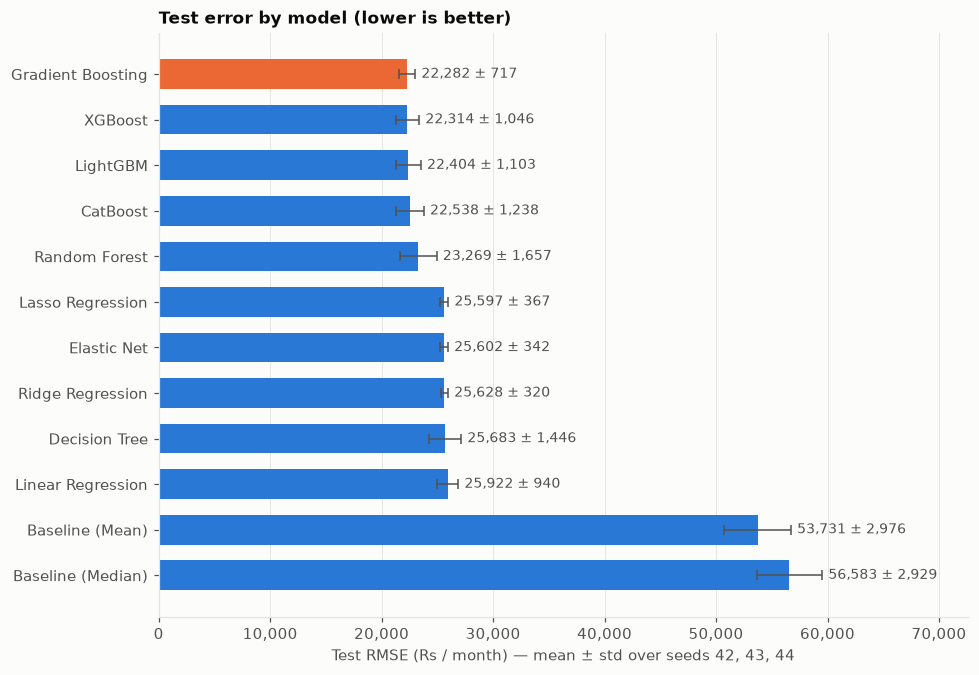

In [3]:
best = num.sort_values('Test RMSE mean')['Model'].iloc[0]
fig = plot_model_comparison(num, highlight=best, save_path=config.VIZ_DIR / 'model_comparison.png')

## 4. Overfitting check — how much worse is unseen data than training data?

In [4]:
gap = num.set_index('Model')[['Train RMSE mean', 'CV RMSE mean', 'Test RMSE mean']]
gap.columns = ['Train RMSE', 'CV RMSE', 'Test RMSE']
gap['CV − Train'] = gap['CV RMSE'] - gap['Train RMSE']
gap.sort_values('Test RMSE')

,Train RMSE,CV RMSE,Test RMSE,CV − Train
Model,,,,
Gradient Boosting,"26,667.16","29,049.61","22,281.94","2,382.45"
XGBoost,"20,535.75","29,051.19","22,313.70","8,515.44"
LightGBM,"20,546.49","29,009.18","22,403.98","8,462.69"
CatBoost,"12,563.17","29,939.13","22,537.95","17,375.96"
Random Forest,"13,996.02","30,482.34","23,268.79","16,486.32"
Lasso Regression,"33,473.80","32,811.02","25,596.64",-662.78
Elastic Net,"33,500.25","32,824.69","25,601.60",-675.56
Ridge Regression,"33,424.34","32,945.10","25,627.73",-479.24
Decision Tree,"27,139.65","31,484.96","25,682.79","4,345.31"


**Reading it.** Lower is better. One model is clearly better than another only when the gap between their means is
large compared with their ± spreads — the top boosting models are close to a tie. A large positive *CV − Train* means
the model fits its training rows much better than rows it has not seen (overfitting); the baselines have none because
they predict a constant.